<a href="https://colab.research.google.com/github/beena24/Research_works/blob/main/lasso_optz_TPOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load dataset
# data = pd.read_csv('../dataset_2.csv')
data = pd.read_csv('/content/drive/MyDrive/final_radiomics.csv')
data.shape

(1431, 94)

In [ ]:
data.head()

In [ ]:
# separate train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(labels=['class_label'], axis=1),
    data['class_label'],
    test_size=0.2,
    random_state=0)

X_train.shape, X_test.shape

((1144, 93), (287, 93))

In [ ]:
# linear models benefit from feature scaling

scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:
# here I will do the model fitting and feature selection
# altogether in one line of code

# first I specify the Logistic Regression model, and I
# make sure I select the Lasso (l1) penalty.

# Then I use the selectFromModel class from sklearn, which
# will select the features which coefficients are non-zero

sel_ = SelectFromModel(
    LogisticRegression(C=0.5, penalty='l1', solver='liblinear', random_state=10))

sel_.fit(scaler.transform(X_train), y_train)

SelectFromModel(estimator=LogisticRegression(C=0.5, penalty='l1',
                                             random_state=10,
                                             solver='liblinear'))

In [ ]:
# this command let's me visualise the index of the
# features that were selected

ch = sel_.get_support()
len(sel_.get_support())

93

In [ ]:
names = X_train.columns.tolist()

In [ ]:
selected_features = [v for i,v in enumerate(names) if ch[i] == True]

In [ ]:
ch

In [ ]:
# Now I make a list with the selected features
selected_feat = X_train.columns[(sel_.get_support())]

print('total features: {}'.format((X_train.shape[1])))
print('selected features: {}'.format(len(selected_feat)))
print('features with coefficients shrank to zero: {}'.format(
    np.sum(sel_.estimator_.coef_ == 0)))

total features: 93
selected features: 51
features with coefficients shrank to zero: 200


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
rf = RandomForestClassifier(n_estimators=50,
                            max_depth=4,
                            random_state=50,
                            n_jobs=4)

rf.fit(X_train[selected_features], y_train)

# print roc-auc in train and testing sets
print(
    'train auc score: ',
    roc_auc_score(y_train, (rf.predict_proba(X_train[selected_features])), multi_class='ovo'))
print(
    'test auc score: ',
    roc_auc_score(y_test, (rf.predict_proba(X_test[selected_features])), multi_class='ovo'))

train auc score:  0.9620938537867562
test auc score:  0.9229635129725882


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred = rf.predict(X_test[selected_features])

# Create and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[75  9  8]
 [ 6 88  8]
 [16 10 67]]


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

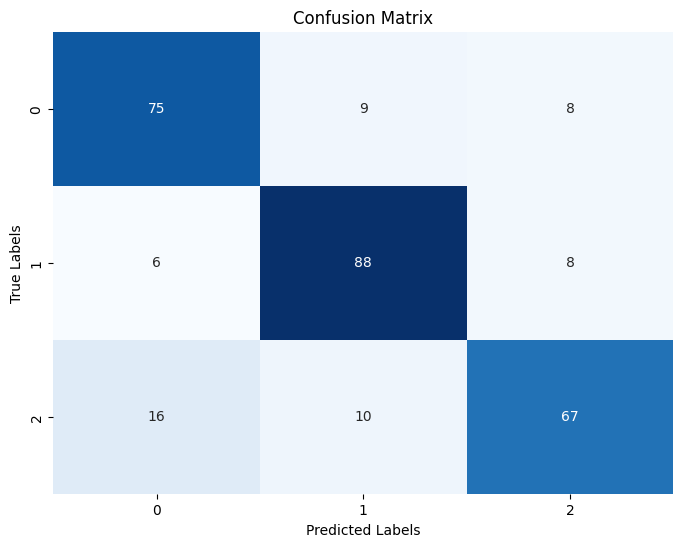

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot colorful confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn import ensemble
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pylab as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score

from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import classification_report

In [ ]:
params = {'loss': 'deviance', ##  loss{‘deviance’, ‘exponential’}, default=’deviance’
          'learning_rate': 0.02, ##  learning_ratefloat, default=0.1
          'n_estimators': 50, ##  number of iterations, int, default=100
          'max_depth': 3, ##  int, default=3
          'subsample': 0.6, ## float, default=1.0
          'min_samples_split': 2 ## int or float, default=2
          }

# params = {'loss': 'deviance', ##  loss{‘deviance’, ‘exponential’}, default=’deviance’
#           'learning_rate': 0.2, ##  learning_ratefloat, default=0.1
#           'n_estimators': 100, ##  number of iterations, int, default=100
#           'max_depth': 3, ##  int, default=3
#           'subsample': 0.6, ## float, default=1.0
#           'min_samples_split': 2 ## int or float, default=2
#           }
clf_GB = ensemble.GradientBoostingClassifier(**params)
print(cross_val_score(clf_GB, X_train[selected_features], y_train, cv=5))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:280: FutureWarning: The loss parameter name 'deviance' was deprecated in v1.1 and will be removed in version 1.3. Use the new parameter name 'log_loss' which is equivalent.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:280: FutureWarning: The loss parameter name 'deviance' was deprecated in v1.1 and will be removed in version 1.3. Use the new parameter name 'log_loss' which is equivalent.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:280: FutureWarning: The loss parameter name 'deviance' was deprecated in v1.1 and will be removed in version 1.3. Use the new parameter name 'log_loss' which is equivalent.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:280: FutureWarning: The loss parameter name 'deviance' was deprecated in v1.1 and will be removed in version 1.3. Use the new parameter name 'log_loss' which is equivalent.
 

[0.84279476 0.8558952  0.8209607  0.8209607  0.84210526]


In [ ]:
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score

from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import classification_report

In [ ]:
# params = {'loss': 'deviance', ##  loss{‘deviance’, ‘exponential’}, default=’deviance’
#           'learning_rate': 0.2, ##  learning_ratefloat, default=0.1
#           'n_estimators': 100, ##  number of iterations, int, default=100
#           'max_depth': 3, ##  int, default=3
#           'subsample': 0.6, ## float, default=1.0
#           'min_samples_split': 2 ## int or float, default=2
#           }


params = {'loss': 'deviance', ##  loss{‘deviance’, ‘exponential’}, default=’deviance’
          'learning_rate': 0.02, ##  learning_ratefloat, default=0.1
          'n_estimators': 50, ##  number of iterations, int, default=100
          'max_depth': 6, ##  int, default=3
          'subsample': 0.6, ## float, default=1.0
          'min_samples_split': 2 ## int or float, default=2
          }
clf_GB = ensemble.GradientBoostingClassifier(**params)
clf_GB.fit(X_train[selected_features], y_train)
preds_GB = clf_GB.predict(X_test[selected_features])
print(classification_report(y_test, preds_GB))
cm_test_GB = confusion_matrix(y_test, preds_GB)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:280: FutureWarning: The loss parameter name 'deviance' was deprecated in v1.1 and will be removed in version 1.3. Use the new parameter name 'log_loss' which is equivalent.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.77      0.82      0.79        92
           1       0.83      0.84      0.84       102
           2       0.83      0.77      0.80        93

    accuracy                           0.81       287
   macro avg       0.81      0.81      0.81       287
weighted avg       0.81      0.81      0.81       287



In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.2, 0.4]
n_estimators_list = [100, 500, 1000]

i = 0
plt.figure(figsize=(15,10))

for est in n_estimators_list:

    i = i + 1
    scores = list()
    score_tests = list()

    for rate in learning_rates:

        params = {'loss': 'deviance', ##  loss{‘deviance’, ‘exponential’}, default=’deviance’
              'learning_rate': rate, ##  learning_ratefloat, default=0.1
              'n_estimators': est, ##  number of iterations, int, default=100
              'max_depth': 3, ##  int, default=3
              'subsample': 1, ## float, default=1.0
              'min_samples_split': 2 ## int or float, default=2
              }
        clf_cv = ensemble.GradientBoostingClassifier(**params)
        clf_cv.fit(X_train[selected_features], y_train)
        cv_score = clf_cv.score(X_train[selected_features], y_train)
        scores.append(np.mean(cv_score))
        score_test = clf_cv.score(X_test[selected_features], y_test)
        score_tests.append(score_test)

    plt.subplot(1,3,i)
    plt.semilogx(learning_rates, scores, 'b')
    plt.semilogx(learning_rates, score_tests, 'r')
    plt.title('N estimators = {}'.format(est))
    plt.xlabel('learning rate')
    plt.ylabel('Accuracy')
    plt.ylim(0,1.1)

plt.show()

In [ ]:
clf_RF = ensemble.RandomForestClassifier(n_estimators=50, max_depth=4,
                                         random_state=50,
                                         n_jobs=4)
print(cross_val_score(clf_RF, X_train[selected_features], y_train, cv=5))
clf_RF.fit(X_train[selected_features], y_train)
preds_RF = clf_RF.predict(X_test[selected_features])
print(classification_report(y_test, preds_RF))
cm_test_RF = confusion_matrix(y_test, preds_RF)


[0.82532751 0.85152838 0.81222707 0.83406114 0.83333333]
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        92
           1       0.82      0.86      0.84       102
           2       0.81      0.72      0.76        93

    accuracy                           0.80       287
   macro avg       0.80      0.80      0.80       287
weighted avg       0.80      0.80      0.80       287



In [ ]:
# the number of features which coefficient was shrank to zero:
np.sum(sel_.estimator_.coef_ == 0)

200

In [ ]:
len((sel_.estimator_.coef_ == 0).ravel().tolist())

279

In [ ]:
len(X_train.columns.tolist())

93

In [ ]:
# we can then remove the features from the training and testing set
# like this:

X_train_selected = sel_.transform(X_train)
X_test_selected = sel_.transform(X_test)

X_train_selected.shape, X_test_selected.shape

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


((1144, 51), (287, 51))

In [ ]:
# For comparison, I will fit a logistic regression with a
# Ridge regularisation, and evaluate the coefficients

l1_logit = LogisticRegression(C=0.5, penalty='l2', max_iter=300, random_state=10)
l1_logit.fit(scaler.transform(X_train), y_train)

# I count the number of coefficients with zero values
# and it is zero, as expected
np.sum(l1_logit.coef_ == 0)

0

Optimization Methods


GA-TPOT(RF)

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt','log2']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 1000,10)]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10,14]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4,6,8]
# Create the random grid
param = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
              'criterion':['entropy','gini']}
print(param)

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt', 'log2'], 'max_depth': [10, 120, 230, 340, 450, 560, 670, 780, 890, 1000], 'min_samples_split': [2, 5, 10, 14], 'min_samples_leaf': [1, 2, 4, 6, 8], 'criterion': ['entropy', 'gini']}


In [ ]:
import pip

/usr/local/lib/python3.10/dist-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


In [ ]:
!pip install tpot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stopit: filename=stopit-1.1.2-py3-none-any.whl size=11938 sha256=150206f6ddd0b6a3e113b2f57e64a5b2db6f3138f9822e44ea48aa10b1f8886e
  Stored in directory: /root/.cache/pip/wheels/af/f9/87/bf5b3d565c2a007b4dae9d8142dccc85a9f164e517062dd519
Successfully built stopit


In [ ]:

from tpot import TPOTClassifier

tpot_classifier = TPOTClassifier(generations= 5, population_size= 24, offspring_size= 12,
                                 verbosity= 2, early_stop= 12,
                                 config_dict={'sklearn.ensemble.RandomForestClassifier': param},
                                 cv = 4, scoring = 'accuracy')
tpot_classifier.fit(X_train[selected_features],y_train)


Optimization Progress:   0%|          | 0/84 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 0.8409090909090908

Generation 2 - Current best internal CV score: 0.8409090909090909

Generation 3 - Current best internal CV score: 0.8409090909090909

Generation 4 - Current best internal CV score: 0.8417832167832168

Generation 5 - Current best internal CV score: 0.8426573426573426

Best pipeline: RandomForestClassifier(input_matrix, criterion=entropy, max_depth=120, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=1800)


TPOTClassifier(config_dict={'sklearn.ensemble.RandomForestClassifier': {'criterion': ['entropy',
                                                                                      'gini'],
                                                                        'max_depth': [10,
                                                                                      120,
                                                                                      230,
                                                                                      340,
                                                                                      450,
                                                                                      560,
                                                                                      670,
                                                                                      780,
                                                                                      890,
                                                                                      1000],
                                                                        'max_features': ['auto',
                                                                                         'sqrt',
                                                                                         'log2'],
                                                                        'min_samples_leaf': [1,
                                                                                             2,
                                                                                             4,
                                                                                             6,
                                                                                             8],
                                                                        'min_samples_split': [2,
                                                                                              5,
                                                                                              10,
                                                                                              14],
                                                                        'n_estimators': [200,
                                                                                         400,
                                                                                         600,
                                                                                         800,
                                                                                         1000,
                                                                                         1200,
                                                                                         1400,
                                                                                         1600,
                                                                                         1800,
                                                                                         2000]}},
               cv=4, early_stop=12, generations=5, offspring_size=12,
               population_size=24, scoring='accuracy', verbosity=2)

In [ ]:
print(tpot.score(X_train[selected_features],y_train))

In [ ]:
from tpot import TPOTClassifier

tpot_config = {
    # Classifiers
    'sklearn.naive_bayes.GaussianNB': {
    },

    'sklearn.naive_bayes.BernoulliNB': {
        'alpha': [1e-3, 1e-2, 1e-1, 1., 10., 100.],
        'fit_prior': [True, False]
    },

    'sklearn.naive_bayes.MultinomialNB': {
        'alpha': [1e-3, 1e-2, 1e-1, 1., 10., 100.],
        'fit_prior': [True, False]
    },

    'sklearn.tree.DecisionTreeClassifier': {
        'criterion': ["gini", "entropy"],
        'max_depth': range(1, 11),
        'min_samples_split': range(2, 21),
        'min_samples_leaf': range(1, 21)
    },


    'sklearn.neighbors.KNeighborsClassifier': {
        'n_neighbors': range(1, 101),
        'weights': ["uniform", "distance"],
        'p': [1, 2]
    },


    'sklearn.linear_model.LogisticRegression': {
        'penalty': ["l1", "l2"],
        'C': [1e-4, 1e-3, 1e-2, 1e-1, 0.5, 1., 5., 10., 15., 20., 25.],
        'dual': [True, False]
    },

    # Preprocesssors
    'sklearn.preprocessing.Binarizer': {
        'threshold': np.arange(0.0, 1.01, 0.05)
    },

    'sklearn.cluster.FeatureAgglomeration': {
        'linkage': ['ward', 'complete', 'average'],
        'affinity': ['euclidean', 'l1', 'l2', 'manhattan', 'cosine']
    },

    'sklearn.preprocessing.MaxAbsScaler': {
    },

    'sklearn.preprocessing.MinMaxScaler': {
    },

    'sklearn.preprocessing.Normalizer': {
        'norm': ['l1', 'l2', 'max']
    },

    'sklearn.decomposition.PCA': {
        'svd_solver': ['randomized'],
        'iterated_power': range(1, 11)
    },

    'sklearn.kernel_approximation.RBFSampler': {
        'gamma': np.arange(0.0, 1.01, 0.05)
    },

    'sklearn.preprocessing.RobustScaler': {
    },

    'sklearn.preprocessing.StandardScaler': {
    },

    'tpot.builtins.ZeroCount': {
    },

    # Selectors
    'sklearn.feature_selection.SelectFwe': {
        'alpha': np.arange(0, 0.05, 0.001),
        'score_func': {
            'sklearn.feature_selection.f_classif': None
        }
    },

    'sklearn.feature_selection.SelectPercentile': {
        'percentile': range(1, 100),
        'score_func': {
            'sklearn.feature_selection.f_classif': None
        }
    },

    'sklearn.feature_selection.VarianceThreshold': {
        'threshold': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
    }

}
tpot = TPOTClassifier(generations=5, population_size=20, verbosity=2,
                      config_dict=tpot_config)
tpot.fit(X_train[selected_features],y_train)

print(tpot.score(X_test[selected_features], y_test))
tpot.export('tpot_digits_pipeline.py')

Optimization Progress:   0%|          | 0/120 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 0.837405194208228

Generation 2 - Current best internal CV score: 0.840032942618555

Generation 3 - Current best internal CV score: 0.840032942618555

Generation 4 - Current best internal CV score: 0.840032942618555

Generation 5 - Current best internal CV score: 0.840032942618555

Best pipeline: LogisticRegression(RobustScaler(input_matrix), C=5.0, dual=False, penalty=l2)
0.8153310104529616


In [ ]:
from tpot import TPOTClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
pot = TPOTClassifier(
    generations=5,
    population_size=20,
    verbosity=2,
    scoring='accuracy',
    random_state=42,
    disable_update_check=True,
    config_dict='TPOT light'
)
pot.fit(X_train[selected_features], y_train)

Optimization Progress:   0%|          | 0/120 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 0.828652417068873

Generation 2 - Current best internal CV score: 0.828652417068873

Generation 3 - Current best internal CV score: 0.838282387190684

Generation 4 - Current best internal CV score: 0.838282387190684

Generation 5 - Current best internal CV score: 0.8400329426185552

Best pipeline: KNeighborsClassifier(StandardScaler(input_matrix), n_neighbors=16, p=1, weights=uniform)


TPOTClassifier(config_dict='TPOT light', disable_update_check=True,
               generations=5, population_size=20, random_state=42,
               scoring='accuracy', verbosity=2)

In [ ]:
print(pot.score(X_test, y_test))
pipeline_optimizer.export('tpot_exported_pipeline.py')

In [ ]:
# Evaluate the performance on the test set
y_pred2 = pot.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred2)
print(f"Accuracy: {accuracy:.2f}")

# Calculate precision
precision = precision_score(y_test, y_pred2, average='micro')
print(f"Precision: {precision:.4f}")

# Calculate recall
recall = recall_score(y_test, y_pred2, average='micro')
print(f"Recall: {recall:.4f}")

# Calculate F1 score
f1 = f1_score(y_test, y_pred2,average='micro')
print(f"F1 Score: {f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred2)
print("Confusion Matrix:")
print(conf_matrix)

In [ ]:
pot1 = TPOTClassifier(
    generations=5,
    population_size=20,
    verbosity=2,
    scoring='accuracy',
    random_state=42,
    disable_update_check=True,
    config_dict='TPOT sparse'
)
pot1.fit(X_train[selected_features], y_train)

Optimization Progress:   0%|          | 0/120 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 0.8452731172910442

Generation 2 - Current best internal CV score: 0.8452731172910442

Generation 3 - Current best internal CV score: 0.8470313337929978

Generation 4 - Current best internal CV score: 0.8531333792997777

Generation 5 - Current best internal CV score: 0.8531333792997777

Best pipeline: XGBClassifier(input_matrix, learning_rate=0.1, max_depth=4, min_child_weight=11, n_estimators=100, n_jobs=1, subsample=0.6500000000000001, verbosity=0)


TPOTClassifier(config_dict='TPOT sparse', disable_update_check=True,
               generations=5, population_size=20, random_state=42,
               scoring='accuracy', verbosity=2)

In [ ]:
import numpy as np

classifier_config = {
    'tpot.builtins.OneHotEncoder': {
        'minimum_fraction': [0.05, 0.1, 0.15, 0.2, 0.25]
    },

    'sklearn.neighbors.KNeighborsClassifier': {
        'n_neighbors': range(1, 101),
        'weights': ["uniform", "distance"],
        'p': [1, 2]
    },

    'sklearn.ensemble.RandomForestClassifier': {
        'n_estimators': [100],
        'criterion': ["gini", "entropy"],
        'max_features': np.arange(0.05, 1.01, 0.05),
        'min_samples_split': range(2, 21),
        'min_samples_leaf':  range(1, 21),
        'bootstrap': [True, False]
    },

    'sklearn.feature_selection.SelectFwe': {
        'alpha': np.arange(0, 0.05, 0.001),
        'score_func': {
            'sklearn.feature_selection.f_classif': None
        }
    },

    'sklearn.feature_selection.SelectPercentile': {
        'percentile': range(1, 100),
        'score_func': {
            'sklearn.feature_selection.f_classif': None
        }
    },

    'sklearn.feature_selection.VarianceThreshold': {
        'threshold': np.arange(0.05, 1.01, 0.05)
    },

    'sklearn.feature_selection.RFE': {
        'step': np.arange(0.05, 1.01, 0.05),
        'estimator': {
            'sklearn.ensemble.ExtraTreesClassifier': {
                'n_estimators': [100],
                'criterion': ['gini', 'entropy'],
                'max_features': np.arange(0.05, 1.01, 0.05)
            }
        }
    },

    'sklearn.feature_selection.SelectFromModel': {
        'threshold': np.arange(0, 1.01, 0.05),
        'estimator': {
            'sklearn.ensemble.ExtraTreesClassifier': {
                'n_estimators': [100],
                'criterion': ['gini', 'entropy'],
                'max_features': np.arange(0.05, 1.01, 0.05)
            }
        }
    },

    'sklearn.linear_model.LogisticRegression': {
        'penalty': ["l1", "l2"],
        'C': [1e-4, 1e-3, 1e-2, 1e-1, 0.5, 1., 5., 10., 15., 20., 25.],
        'dual': [True, False]
    },

    'sklearn.naive_bayes.BernoulliNB': {
        'alpha': [1e-3, 1e-2, 1e-1, 1., 10., 100.],
        'fit_prior': [True, False]
    },

    'sklearn.naive_bayes.MultinomialNB': {
        'alpha': [1e-3, 1e-2, 1e-1, 1., 10., 100.],
        'fit_prior': [True, False]
    },

    'sklearn.svm.LinearSVC': {
        'penalty': ["l1", "l2"],
        'loss': ["hinge", "squared_hinge"],
        'dual': [True, False],
        'tol': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        'C': [1e-4, 1e-3, 1e-2, 1e-1, 0.5, 1., 5., 10., 15., 20., 25.]
    },

    'xgboost.XGBClassifier': {
        'n_estimators': [100],
        'max_depth': range(1, 11),
        'learning_rate': [1e-3, 1e-2, 1e-1, 0.5, 1.],
        'subsample': np.arange(0.05, 1.01, 0.05),
        'min_child_weight': range(1, 21),
        'n_jobs': [1],
        'verbosity': [0]
    }
}
tpot = TPOTClassifier(generations=5, population_size=20, verbosity=2,
                      config_dict=classifier_config)
tpot.fit(X_train[selected_features],y_train)

print(tpot.score(X_test[selected_features], y_test))
tpot.export('tpot_digits_pipeline.py')

Optimization Progress:   0%|          | 0/120 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 0.8400367731555963

Generation 2 - Current best internal CV score: 0.8400367731555963

Generation 3 - Current best internal CV score: 0.8426606910288822

Generation 4 - Current best internal CV score: 0.844395924308588

Generation 5 - Current best internal CV score: 0.844395924308588

Best pipeline: RandomForestClassifier(input_matrix, bootstrap=False, criterion=entropy, max_features=0.2, min_samples_leaf=3, min_samples_split=11, n_estimators=100)
0.8222996515679443


In [ ]:
config_dict1={
               'sklearn.ensemble.RandomForestRegressor': {'n_estimators': [20, 100, 200, 500, 1000],
                                                              'max_features': [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95],
                                                              'min_samples_split': range(2, 21, 3),
                                                              'min_samples_leaf': range(1, 21, 3),
                                                              'bootstrap': [True, False]},

               'sklearn.ensemble.GradientBoostingRegressor': {'n_estimators': [20, 100, 200, 500, 1000],
                                                              'loss': ['ls', 'lad', 'huber', 'quantile'],
                                                              'learning_rate': [0.01, 0.1, 0.5, 1.0],
                                                              'max_depth': range(1, 11, 2),
                                                              'min_samples_split': range(2, 21, 3),
                                                              'min_samples_leaf': range(1, 21, 3),
                                                              'subsample': [0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
                                                                                  0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.],
                                                              'max_features': [0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
                                                                                     0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.],
                                                              'alpha': [0.75, 0.8, 0.85, 0.9, 0.95, 0.99]},

               'sklearn.ensemble.ExtraTreesRegressor': {'n_estimators': [20, 100, 200, 500, 1000],
                                                        'max_features': [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95],
                                                        'min_samples_split': range(2, 21, 3),
                                                        'min_samples_leaf': range(1, 21, 3),
                                                        'bootstrap': [True, False]},

               'sklearn.tree.DecisionTreeRegressor': {'max_depth': range(1, 11, 2),
                                                      'min_samples_split': range(2, 21, 3),
                                                      'min_samples_leaf': range(1, 21, 3)},

               'sklearn.neighbors.KNeighborsRegressor': {'n_neighbors': range(1, 101),
                                                         'weights': ['uniform', 'distance'],
                                                         'p': [1, 2]},

               'sklearn.linear_model.Lasso': {'alpha': [1e-2, 1e-1, 1e0, 1e1, 1e2]}, #J alpha values taken from Takigawa-2019

               'sklearn.linear_model.LassoLarsCV': {'normalize': [True, False]},

               'sklearn.linear_model.RidgeCV': {},

               'sklearn.linear_model.ElasticNetCV': {'l1_ratio': [0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ],
                                                     'tol': [1e-05, 0.0001, 0.001, 0.01, 0.1]},
               'sklearn.preprocessing.MaxAbsScaler': {},
               'sklearn.preprocessing.RobustScaler': {},
               'sklearn.preprocessing.StandardScaler': {},
               'sklearn.preprocessing.MinMaxScaler': {},
               'sklearn.preprocessing.Normalizer': {'norm': ['l1', 'l2', 'max']},


               'sklearn.preprocessing.PolynomialFeatures': {'degree': [2],
                                                           'include_bias': [False],
                                                           'interaction_only': [False]},

               'sklearn.kernel_approximation.RBFSampler': {'gamma': [0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]},


               'sklearn.kernel_approximation.Nystroem': {'kernel': ['rbf', 'cosine', 'chi2', 'laplacian', 'polynomial', 'poly', 'linear', 'additive_chi2','sigmoid'],
                                                         'gamma': [0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ],
                                                         'n_components': range(1, 11)},

               'tpot.builtins.ZeroCount': {},

               'tpot.builtins.OneHotEncoder': {'minimum_fraction': [0.05, 0.1, 0.15, 0.2, 0.25],
                                               'sparse': [False],
                                               'threshold': [10]},

               'sklearn.preprocessing.Binarizer': {'threshold': [0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
                      0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]},

               'sklearn.cluster.FeatureAgglomeration': {'linkage': ['ward', 'complete', 'average'],
                                                        'affinity': ['euclidean', 'l1', 'l2', 'manhattan', 'cosine']},




               'sklearn.feature_selection.SelectPercentile': {'percentile': range(1, 100),
                                                              'score_func': {'sklearn.feature_selection.f_regression': None}},


               'sklearn.decomposition.PCA': {'svd_solver': ['randomized'],
                                             'iterated_power': range(1, 11)},

               'sklearn.decomposition.FastICA': {'tol': [0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
                                                         0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]},


               'sklearn.feature_selection.VarianceThreshold': {'threshold': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2]}}
from automatminer.pipeline import MatPipe
config = get_preset_config("production")

config["learner"] = TPOTAdaptor(max_time_mins=1440,
                                max_eval_time_mins=20,
                                cv=5,
                                verbosity=3,
                                memory='auto',
                                template='Selector-Transformer-Regressor',
                                scoring='neg_mean_absolute_error',
                                config_dict=config_dict_1)
pipe = MatPipe(**config)

predicted_folds = pipe.benchmark(df=df, target=target, kfold=kf)



tpot = TPOTClassifier(generations=5, population_size=20, verbosity=2,
                      config_dict=config_dict1)
tpot.fit(X_train[selected_features],y_train)

print(tpot.score(X_test[selected_features], y_test))
tpot.export('tpot_digits_pipeline.py')




In [ ]:
!pip install pymatgen==2020.01.28
!pip install matminer==0.6.2

In [ ]:
!pip3 install -U video-to-ascii==1.2.8

In [ ]:
accuracy = tpot_classifier.score(X_test[selected_features], y_test)
print(accuracy)

In [ ]:
tpot = TPOTClassifier(generations=5, population_size=20, verbosity=2)
import time
start = time.time()
tpot.fit(X_train[selected_features], y_train)
end = time.time()
print('time: ',(end-start))
print('accuracy :', tpot.score(X_test[selected_features], y_test))
tpot.export('tpot_mnist_like_digits_pipeline.py')

Optimization Progress:   0%|          | 0/120 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 0.8426568604918409

Generation 2 - Current best internal CV score: 0.8426568604918409

Generation 3 - Current best internal CV score: 0.8444035853826707

Generation 4 - Current best internal CV score: 0.8452692867540028

Generation 5 - Current best internal CV score: 0.8452692867540028

Best pipeline: GradientBoostingClassifier(input_matrix, learning_rate=0.5, max_depth=7, max_features=0.5, min_samples_leaf=9, min_samples_split=10, n_estimators=100, subsample=0.5)
time:  500.42043685913086
accuracy : 0.8048780487804879


Random Search

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt','log2']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 1000,10)]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10,14]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4,6,8]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
              'criterion':['entropy','gini']}
print(random_grid)

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt', 'log2'], 'max_depth': [10, 120, 230, 340, 450, 560, 670, 780, 890, 1000], 'min_samples_split': [2, 5, 10, 14], 'min_samples_leaf': [1, 2, 4, 6, 8], 'criterion': ['entropy', 'gini']}


In [ ]:
rf=RandomForestClassifier()
rf_randomcv=RandomizedSearchCV(estimator=rf,param_distributions=random_grid,n_iter=100,cv=3,verbose=2,
                               random_state=100,n_jobs=-1)
# fit to randomized rf
rf_randomcv.fit(X_train[selected_features],y_train)

In [ ]:
# to see best parameters
rf_randomcv.best_params_

# to make new classifier with the best estimator
best_random_grid=rf_randomcv.best_estimator_

Bat Algorithm

In [ ]:
!pip install sklearn-nature-inspired-algorithms

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 36.2 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
   'n_estimators': range(10, 80, 20),
   'max_depth': [2, 4, 6, 8, 10, 20],
   'min_samples_split': range(2, 8, 2),
   #'max_features': ["auto", "sqrt", "log2"]

   }

In [ ]:
from sklearn_nature_inspired_algorithms.model_selection import NatureInspiredSearchCV
nia_search = NatureInspiredSearchCV(
    clf,
    param_grid,
    cv=5,
    verbose=1,
    algorithm='ba',
    population_size=25,
    max_n_gen=100,
    max_stagnating_gen=10,
    runs=5,
    scoring='f1_macro',
    random_state=42,
    error_score='raise'
)

nia_search.fit(X_train[selected_features], y_train)

Fitting 5 folds for some of the 72 candidates, which might total in 360 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidat

NatureInspiredSearchCV(algorithm='ba', cv=5, error_score='raise',
                       estimator=RandomForestClassifier(random_state=42),
                       max_stagnating_gen=10,
                       param_grid={'max_depth': [2, 4, 6, 8, 10, 20],
                                   'min_samples_split': range(2, 8, 2),
                                   'n_estimators': range(10, 80, 20)},
                       population_size=25, random_state=42, runs=5,
                       scoring='f1_macro', verbose=1)

In [ ]:
from sklearn.metrics import classification_report
clf = RandomForestClassifier(**nia_search.best_params_, random_state=42)

clf.fit(X_train[selected_features], y_train)

y_pred = clf.predict(X_test[selected_features])

print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81        92
           1       0.82      0.87      0.85       102
           2       0.85      0.75      0.80        93

    accuracy                           0.82       287
   macro avg       0.82      0.82      0.82       287
weighted avg       0.82      0.82      0.82       287



In [ ]:
!pip install optunity

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for optunity: filename=Optunity-1.1.1-py3-none-any.whl size=72028 sha256=362c47df598ba07ff1fed7f302c4a2bf8732df9b0c16075481aa7e35ad0003a8
  Stored in directory: /root/.cache/pip/wheels/83/98/40/b9956c3386a045f035f9edbf894edd04713db92f29fb58a225
Successfully built optunity


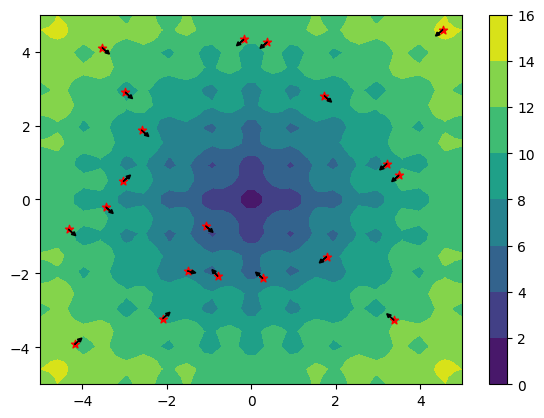

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

The swarm has met convergence criteria after 47 iterrations.


In [ ]:
import math
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import numpy as np

DIMENSIONS = 2              # Number of dimensions
GLOBAL_BEST = 0             # Global Best of Cost function
B_LO = -5                   # Upper boundary of search space
B_HI = 5                    # Upper boundary of search space

POPULATION = 20             # Number of particles in the swarm
V_MAX = 0.1                 # Maximum velocity value
PERSONAL_C = 2.0            # Personal coefficient factor
SOCIAL_C = 2.0              # Social coefficient factor
CONVERGENCE = 0.001         # Convergence value
MAX_ITER = 100              # Maximum number of iterrations

# Particle class
class Particle():
    def __init__(self, x, y, z, velocity):
        self.pos = [x, y]
        self.pos_z = z
        self.velocity = velocity
        self.best_pos = self.pos.copy()

class Swarm():
    def __init__(self, pop, v_max):
        self.particles = []             # List of particles in the swarm
        self.best_pos = None            # Best particle of the swarm
        self.best_pos_z = math.inf      # Best particle of the swarm

        for _ in range(pop):
            x = np.random.uniform(B_LO, B_HI)
            y = np.random.uniform(B_LO, B_HI)
            z = cost_function(x, y)
            velocity = np.random.rand(2) * v_max
            particle = Particle(x, y, z, velocity)
            self.particles.append(particle)
            if self.best_pos != None and particle.pos_z < self.best_pos_z:
                self.best_pos = particle.pos.copy()
                self.best_pos_z = particle.pos_z
            else:
                self.best_pos = particle.pos.copy()
                self.best_pos_z = particle.pos_z

# Evaluate objective/cost function (Ackley)
def cost_function(x, y, a=20, b=0.2, c=2*math.pi):
    term_1 = np.exp((-b * np.sqrt(0.5 * (x ** 2 + y ** 2))))
    term_2 = np.exp((np.cos(c * x) + np.cos(c * y)) / 2)
    return -1 * a * term_1 - term_2 + a + np.exp(1)

def particle_swarm_optimization():

    # Initialize plotting variables
    x = np.linspace(B_LO, B_HI, 50)
    y = np.linspace(B_LO, B_HI, 50)
    X, Y = np.meshgrid(x, y)
    fig = plt.figure("Particle Swarm Optimization")

    # Initialize swarm
    swarm = Swarm(POPULATION, V_MAX)

    # Initialize inertia weight
    inertia_weight = 0.5 + (np.random.rand()/2)

    curr_iter = 0
    while curr_iter < MAX_ITER:

        fig.clf()
        ax = fig.add_subplot(1, 1, 1)
        ac = ax.contourf(X, Y, cost_function(X, Y), cmap='viridis')
        fig.colorbar(ac)

        for particle in swarm.particles:

            for i in range(0, DIMENSIONS):
                r1 = np.random.uniform(0, 1)
                r2 = np.random.uniform(0, 1)

                # Update particle's velocity
                personal_coefficient = PERSONAL_C * r1 * (particle.best_pos[i] - particle.pos[i])
                social_coefficient = SOCIAL_C * r2 * (swarm.best_pos[i] - particle.pos[i])
                new_velocity = inertia_weight * particle.velocity[i] + personal_coefficient + social_coefficient

                # Check if velocity is exceeded
                if new_velocity > V_MAX:
                    particle.velocity[i] = V_MAX
                elif new_velocity < -V_MAX:
                    particle.velocity[i] = -V_MAX
                else:
                    particle.velocity[i] = new_velocity

            ax.scatter(particle.pos[0], particle.pos[1], marker='*', c='r')
            ax.arrow(particle.pos[0], particle.pos[1], particle.velocity[0], particle.velocity[1], head_width=0.1, head_length=0.1, color='k')

            # Update particle's current position
            particle.pos += particle.velocity
            particle.pos_z = cost_function(particle.pos[0], particle.pos[1])

            # Update particle's best known position
            if particle.pos_z < cost_function(particle.best_pos[0], particle.best_pos[1]):
                particle.best_pos = particle.pos.copy()

                # Update swarm's best known position
                if particle.pos_z < swarm.best_pos_z:
                    swarm.best_pos = particle.pos.copy()
                    swarm.best_pos_z = particle.pos_z

            # Check if particle is within boundaries
            if particle.pos[0] > B_HI:
                particle.pos[0] = np.random.uniform(B_LO, B_HI)
                particle.pos_z = cost_function(particle.pos[0], particle.pos[1])
            if particle.pos[1] > B_HI:
                particle.pos[1] = np.random.uniform(B_LO, B_HI)
                particle.pos_z = cost_function(particle.pos[0], particle.pos[1])
            if particle.pos[0] < B_LO:
                particle.pos[0] = np.random.uniform(B_LO, B_HI)
                particle.pos_z = cost_function(particle.pos[0], particle.pos[1])
            if particle.pos[1] < B_LO:
                particle.pos[1] = np.random.uniform(B_LO, B_HI)
                particle.pos_z = cost_function(particle.pos[0], particle.pos[1])

        plt.subplots_adjust(right = 0.95)
        plt.pause(0.00001)

        # Check for convergence
        if abs(swarm.best_pos_z - GLOBAL_BEST) < CONVERGENCE:
            print("The swarm has met convergence criteria after " + str(curr_iter) + " iterrations.")
            break
        curr_iter += 1
    plt.show()

if __name__ == "__main__":
    particle_swarm_optimization()

Fireply

reset the fireflies
Overall best intensity: 45.32836608641666, Overall best Accuracy: 24.274700162863596
Overall best intensity: 87.64513347944431, Overall best Accuracy: 46.936598859344805
Overall best intensity: 87.64513347944431, Overall best Accuracy: 46.936598859344805
Overall best intensity: 106.7209075810802, Overall best Accuracy: 57.15224827871561
Overall best intensity: 129.8954433610819, Overall best Accuracy: 69.56290756435166
Overall best intensity: 144.51467698763622, Overall best Accuracy: 77.39194583630041
Overall best intensity: 144.51467698763622, Overall best Accuracy: 77.39194583630041
Overall best intensity: 183.2689131462777, Overall best Accuracy: 98.1460021594057
Overall best intensity: 183.2689131462777, Overall best Accuracy: 98.1460021594057
Overall best intensity: 183.2689131462777, Overall best Accuracy: 98.1460021594057
Overall best intensity: 183.2689131462777, Overall best Accuracy: 98.1460021594057
Overall best intensity: 183.2689131462777, Overall best

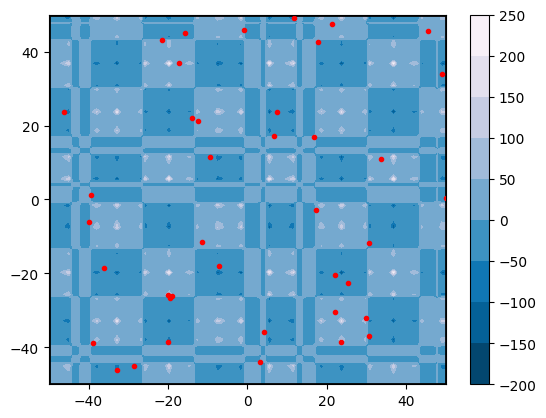

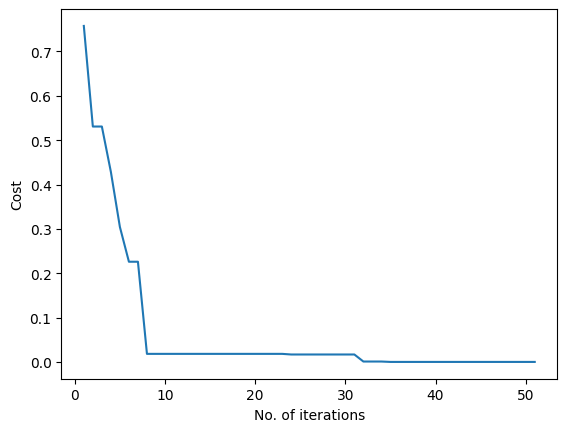

reset the fireflies
Overall best intensity: -11.581142224163774, Overall best Accuracy: 1058.1142224163773
Overall best intensity: -11.547020360928759, Overall best Accuracy: 1054.702036092876
Overall best intensity: -11.225248999247125, Overall best Accuracy: 1022.5248999247125
Overall best intensity: -10.832273069503916, Overall best Accuracy: 983.2273069503916
Overall best intensity: -10.757191837822766, Overall best Accuracy: 975.7191837822767
Overall best intensity: -10.162667593890474, Overall best Accuracy: 916.2667593890474
Overall best intensity: -10.162085472676104, Overall best Accuracy: 916.2085472676104
Overall best intensity: -9.267175248222522, Overall best Accuracy: 826.7175248222521
Overall best intensity: -7.570657778938626, Overall best Accuracy: 657.0657778938627
Overall best intensity: -7.570657778938626, Overall best Accuracy: 657.0657778938627
Overall best intensity: -6.843371659019493, Overall best Accuracy: 584.3371659019492
Overall best intensity: -6.843371659

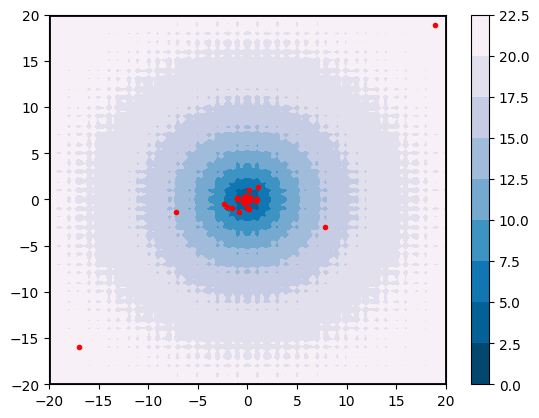

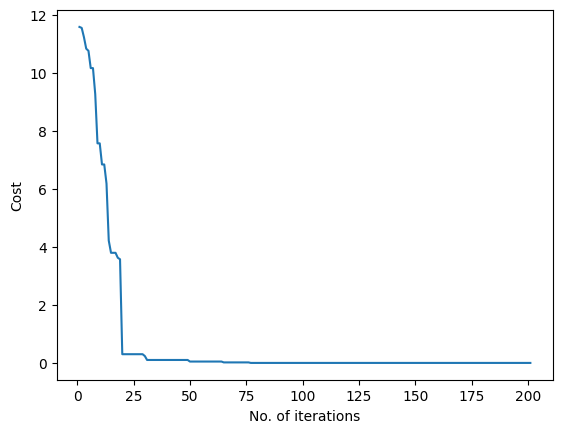

reset the fireflies
Overall best intensity: -161.03406844687854, Overall best Accuracy: 16003.406844687854
Overall best intensity: -1.2747891472629325, Overall best Accuracy: 27.478914726293247
Overall best intensity: -1.2747891472629325, Overall best Accuracy: 27.478914726293247
Overall best intensity: -1.2747891472629325, Overall best Accuracy: 27.478914726293247
Overall best intensity: -0.2959484240806813, Overall best Accuracy: 70.40515759193187
Overall best intensity: -0.0005416101043408866, Overall best Accuracy: 99.94583898956591
Overall best intensity: -0.0005416101043408866, Overall best Accuracy: 99.94583898956591
Overall best intensity: -0.0005416101043408866, Overall best Accuracy: 99.94583898956591
Overall best intensity: -0.0005416101043408866, Overall best Accuracy: 99.94583898956591
Overall best intensity: -0.0005416101043408866, Overall best Accuracy: 99.94583898956591
Overall best intensity: -0.0005416101043408866, Overall best Accuracy: 99.94583898956591
Overall best

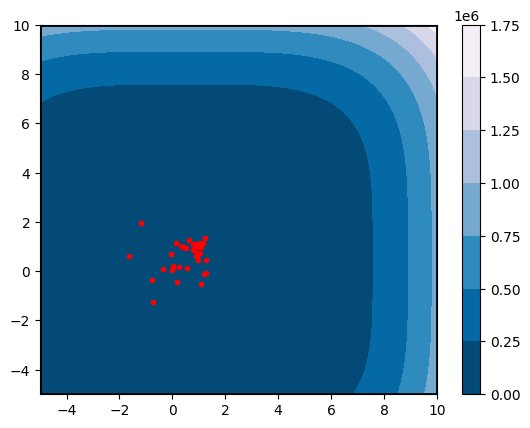

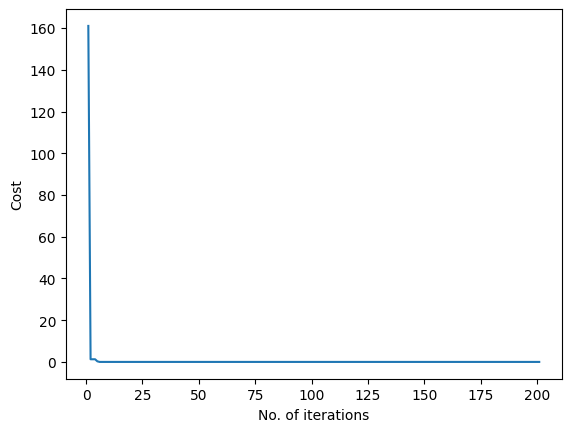

reset the fireflies
Overall best intensity: -0.05119304522498703, Overall best Accuracy: 94.88069547750129
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Overall best intensity: -9.978323233587289e-09, Overall best Accuracy: 99.99999900216767
Ove

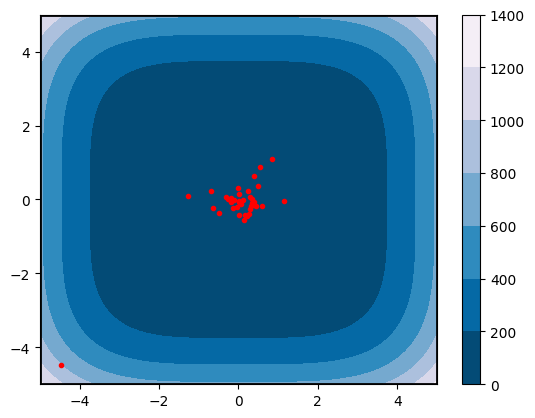

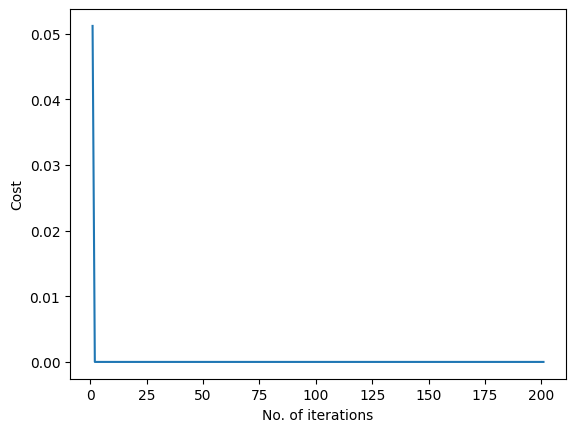

reset the fireflies
Overall best intensity: -0.21759797368069977, Overall best Accuracy: 78.24020263193002
Overall best intensity: -0.0020794881335881588, Overall best Accuracy: 99.79205118664119
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Overall best intensity: -8.330059652794652e-05, Overall best Accuracy: 99.99166994034721
Ove

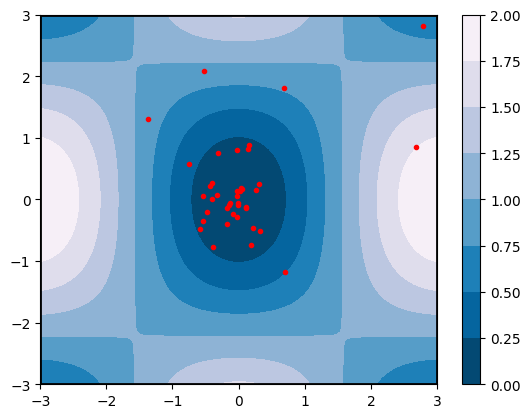

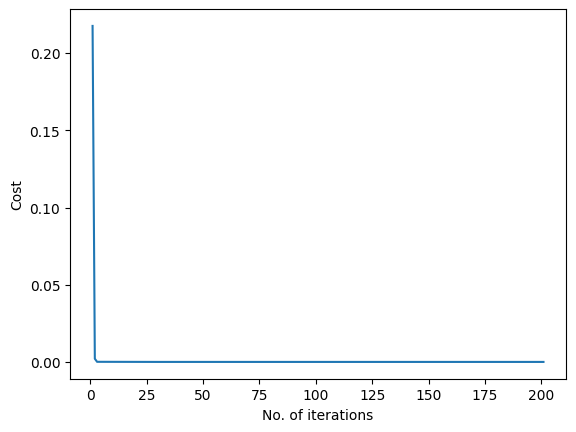

reset the fireflies
Overall best intensity: -0.8149967079135092, Overall best Accuracy: 18.50032920864908
Overall best intensity: -0.5414611069257703, Overall best Accuracy: 45.85388930742297
Overall best intensity: -0.04593335657920007, Overall best Accuracy: 95.40666434207999
Overall best intensity: -0.04593335657920007, Overall best Accuracy: 95.40666434207999
Overall best intensity: -0.03495737759825927, Overall best Accuracy: 96.50426224017407
Overall best intensity: -0.03495737759825927, Overall best Accuracy: 96.50426224017407
Overall best intensity: -0.03495737759825927, Overall best Accuracy: 96.50426224017407
Overall best intensity: -0.03495737759825927, Overall best Accuracy: 96.50426224017407
Overall best intensity: -0.03495737759825927, Overall best Accuracy: 96.50426224017407
Overall best intensity: -0.03495737759825927, Overall best Accuracy: 96.50426224017407
Overall best intensity: -0.03495737759825927, Overall best Accuracy: 96.50426224017407
Overall best intensity: -

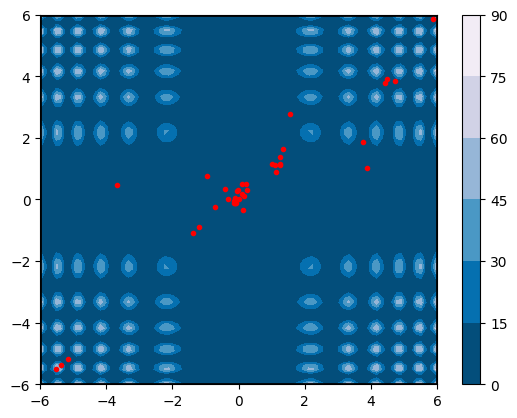

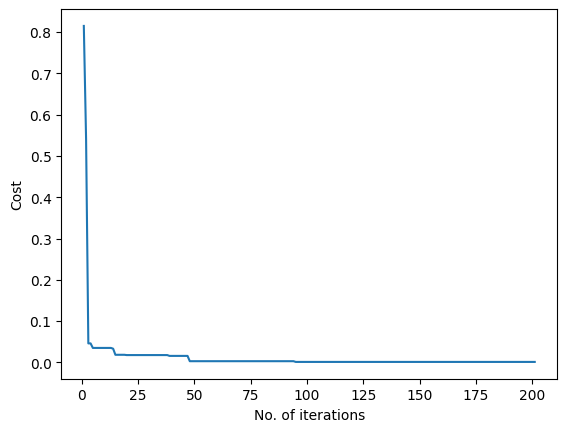

reset the fireflies
Overall best intensity: -7.600191741978621, Overall best Accuracy: 660.0191741978622
Overall best intensity: -3.9856806335210067, Overall best Accuracy: 298.5680633521007
Overall best intensity: -0.6970853885192554, Overall best Accuracy: 30.29146114807446
Overall best intensity: -0.6970853885192554, Overall best Accuracy: 30.29146114807446
Overall best intensity: -0.6970853885192554, Overall best Accuracy: 30.29146114807446
Overall best intensity: -0.6970853885192554, Overall best Accuracy: 30.29146114807446
Overall best intensity: -0.6970853885192554, Overall best Accuracy: 30.29146114807446
Overall best intensity: -0.6140037896227284, Overall best Accuracy: 38.59962103772716
Overall best intensity: -0.4101493844095856, Overall best Accuracy: 58.98506155904144
Overall best intensity: -0.4101493844095856, Overall best Accuracy: 58.98506155904144
Overall best intensity: -0.4101493844095856, Overall best Accuracy: 58.98506155904144
Overall best intensity: -0.41014938

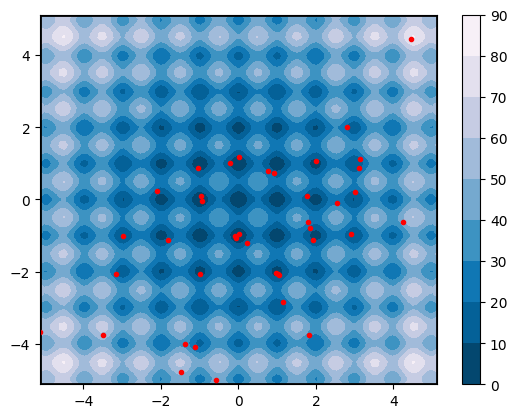

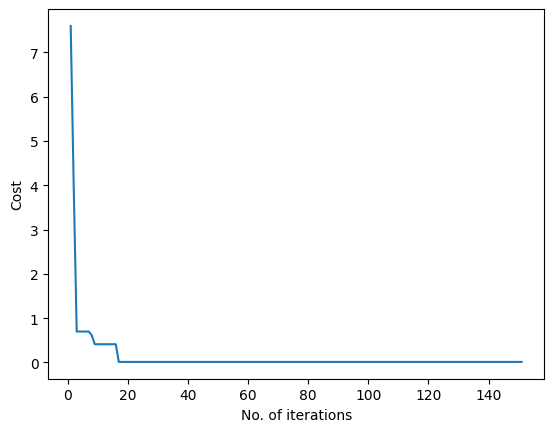

reset the fireflies
Overall best intensity: 1.0437004546219155e-05, Overall best Accuracy: 0.0010437004546171025
Overall best intensity: 1.0437004546219155e-05, Overall best Accuracy: 0.0010437004546171025
Overall best intensity: 0.8340175425033429, Overall best Accuracy: 83.40175425033429
Overall best intensity: 0.8648477150089947, Overall best Accuracy: 86.48477150089948
Overall best intensity: 0.9233753548097423, Overall best Accuracy: 92.33753548097422
Overall best intensity: 0.9886623613941623, Overall best Accuracy: 98.86623613941623
Overall best intensity: 0.9943913539172172, Overall best Accuracy: 99.4391353917217
Overall best intensity: 0.9956739764997956, Overall best Accuracy: 99.56739764997957
Overall best intensity: 0.9963286047870465, Overall best Accuracy: 99.63286047870466
Overall best intensity: 0.9985357541490928, Overall best Accuracy: 99.85357541490929
Overall best intensity: 0.9985357541490928, Overall best Accuracy: 99.85357541490929
Overall best intensity: 0.9993

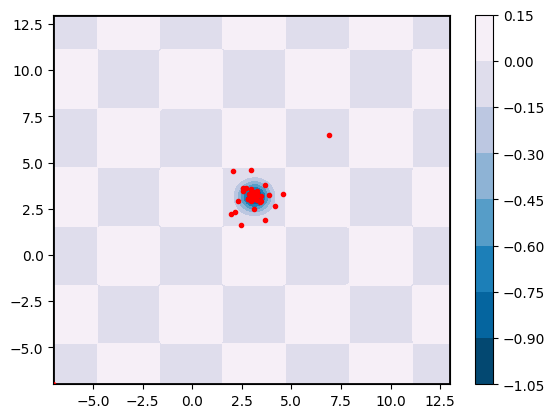

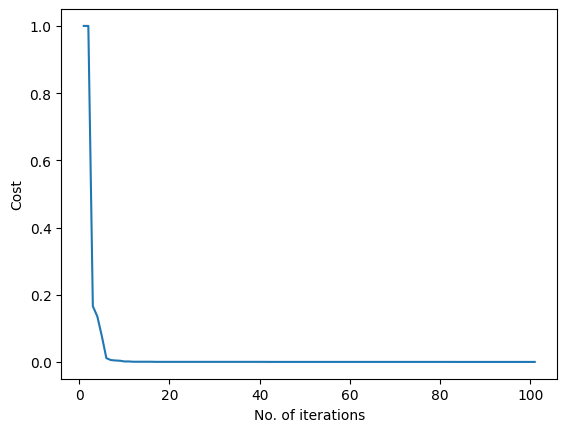

reset the fireflies
Overall best intensity: 0.7991047965924345, Overall best Accuracy: 44.36267121481343
Overall best intensity: 1.515752981569518, Overall best Accuracy: 84.14772561869306
Overall best intensity: 1.5735297773533552, Overall best Accuracy: 87.35523107496559
Overall best intensity: 1.5989563317629705, Overall best Accuracy: 88.76679796607843
Overall best intensity: 1.5989563317629705, Overall best Accuracy: 88.76679796607843
Overall best intensity: 1.6010913594945584, Overall best Accuracy: 88.88532501496466
Overall best intensity: 1.6010913594945584, Overall best Accuracy: 88.88532501496466
Overall best intensity: 1.6010913594945584, Overall best Accuracy: 88.88532501496466
Overall best intensity: 1.6010913594945584, Overall best Accuracy: 88.88532501496466
Overall best intensity: 1.6010913594945584, Overall best Accuracy: 88.88532501496466
Overall best intensity: 1.6010913594945584, Overall best Accuracy: 88.88532501496466
Overall best intensity: 1.6010913594945584, Ov

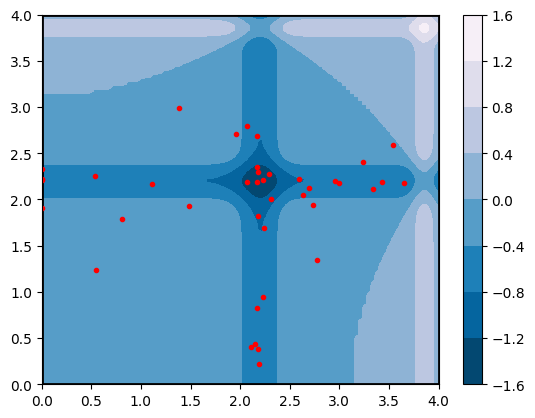

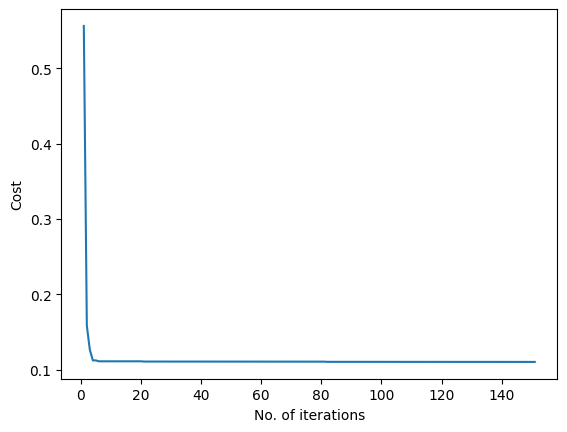

reset the fireflies
Overall best intensity: -1.4755195755380441, Overall best Accuracy: 47.551957553804414
Overall best intensity: -1.4755195755380441, Overall best Accuracy: 47.551957553804414
Overall best intensity: -1.4685115486997802, Overall best Accuracy: 46.85115486997802
Overall best intensity: -1.377696527976127, Overall best Accuracy: 37.76965279761271
Overall best intensity: -1.377696527976127, Overall best Accuracy: 37.76965279761271
Overall best intensity: -1.3765498956289548, Overall best Accuracy: 37.65498956289548
Overall best intensity: -1.3536133747907684, Overall best Accuracy: 35.36133747907684
Overall best intensity: -1.3536133747907684, Overall best Accuracy: 35.36133747907684
Overall best intensity: -1.3536133747907684, Overall best Accuracy: 35.36133747907684
Overall best intensity: -1.3536133747907684, Overall best Accuracy: 35.36133747907684
Overall best intensity: -1.3536133747907684, Overall best Accuracy: 35.36133747907684
Overall best intensity: -1.3536133

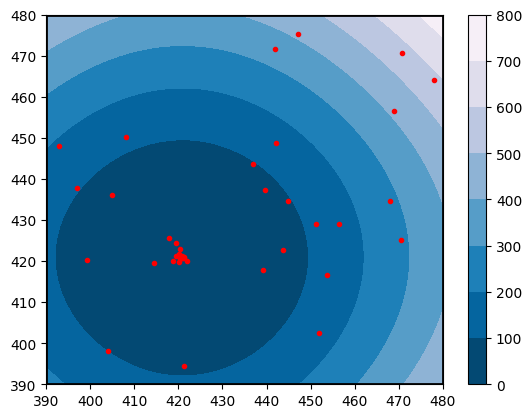

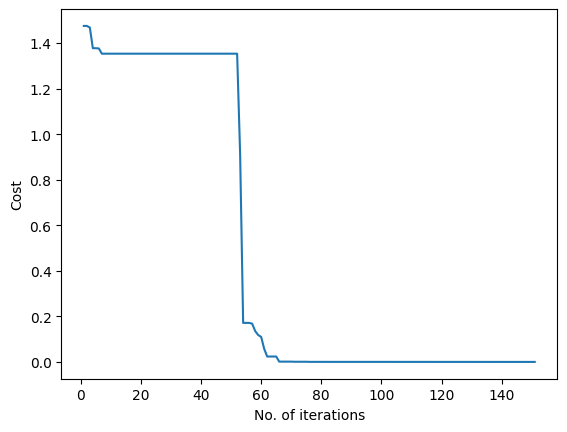

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation,cm
import random
import operator
from functools import reduce
def michalewicz(x):
    result = reduce(lambda acc, x: acc + np.sin(x) * np.power(np.sin((0 + 1) * np.power(x, 2) / np.pi), 2 * 10), x, 0.)
    return -1.0*result

def ackley(x):
    return -20*np.exp(-0.2*np.sqrt((x[0]**2+x[1]**2)/2)) - np.exp(0.5*(np.cos(2*np.pi*x[0]) + np.cos(2*np.pi*x[1]))) + 20 + np.exp(1)

def dejong(x):
    ans = 0
    for i in range(min(len(x),256)):
        ans+=np.power(x[i],4)
    return ans

def yang(x):
#     Yang N.2 function
    temp1 = 0
    temp2 = 0
    for i in range(min(len(x),16)):
        temp2+=np.sin(np.power(x[i],2))
        temp1+=np.absolute(x[i])
    ans =  temp1*np.exp(temp2*-1)
    return ans

def rosenbrock(x):
    ans=0.0
    for i in range(min(len(x),16)):
        ans+=(100.0*(x[i]-x[i]**2)**2 + (1-x[i])**2)
    return ans

def griewank(x):
    ans = 1.0
    inner_product = 1.0
    inner_sum = 0.0
    i=0
    while i < (len(x)):#change to while
        inner_sum += (x[i] ** 2)
        inner_product *= (np.cos(x[i] / np.sqrt(i + 1)))
        i+=1
    ans += (inner_sum * (1. / 4000.) - inner_product)
    return ans

def shubert(x):
        temp1 = 0
        temp2 = 0
        i=0
        while i < (5):
            temp1 += ((i+1)*np.cos((i+1)+(i+2)*x[0]))
            temp2 += ((i+1)*np.cos((i+1)+(i+2)*x[1]))
            i+=1
        return temp1*temp2

def rastrigin(x):
    ans = 0.0
    i=0
    while i< (len(x)):
        ans += (x[i] ** 2 - (10. * np.cos(2 * np.pi * x[i])))
        i+=1
    ans += 10. * len(x)
    return ans

def schwefel(x):
    ans=418.982887*len(x)
    for i in range(min(len(x),128)):
        ans-=x[i]*np.sin(np.sqrt(np.abs(x[i])))
    return ans

def easom(x):
    return -1.0*np.cos(x[0])*np.cos(x[1])*np.exp(-(x[0] - np.pi)**2 - (x[1] - np.pi)**2)

class Firefly():
    def __init__(self, alpha, beta, gamma, ub, lb, function_dimension):
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.brightness = None
        self.lb = lb
        self.ub = ub
        self.posn = np.array([random.uniform(self.lb, self.ub) for x in range(function_dimension)])


    @property
    def intensity(self):
        return self.brightness


    @property
    def position(self):
        return self.posn

    @position.setter
    def position(self, value):
        self.posn = value

    def check_bounds(self):
        for i, cord in np.ndenumerate(self.posn):
            if cord < self.lb:
                self.posn[i] = self.lb
            elif cord > self.ub:
                self.posn[i] = self.ub
            else:
                self.posn[i] = cord
    def update_intensity(self, func):
        self.brightness = -1.*func(self.posn)

    def rand_walk(self, area):
        self.posn = np.array([random.uniform(cord-area, cord+area) for x, cord in np.ndenumerate(self.posn)])

    def move_towards(self, better_position):
        distance = np.linalg.norm(self.posn - better_position)
        self.posn +=   self.beta*np.exp(-self.gamma*(distance**2)) * (better_position-self.posn) +  self.alpha*(random.uniform(0, 1)-0.5)
        self.check_bounds()


class FireflyProblem():

    def __init__(self, function, firefly_number, ub=5.12, lb=-5.12, alpha=2, beta=2, gamma=0.97, iteration_number=50, interval=500, continuous=False):
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.function_dimension = 2
        self.ub = ub
        self.lb = lb
        self.iteration_number = iteration_number
        self.fireflies = [Firefly(self.alpha,self.beta,self.gamma,self.ub,self.lb, self.function_dimension) for x in range(firefly_number)]
        self.function = function
        self.interval = interval
        self.best = None
        self.continuous = continuous
        self.cost=[]
        i=0
        while i<(len(self.fireflies)):
            (self.fireflies)[i].update_intensity(self.function)
            i+=1
    def run(self):
        y = np.linspace(self.lb, self.ub, 100)
        x = np.linspace(self.lb, self.ub, 100)
        X, Y = np.meshgrid(x, y)
        x_init = []
        y_init = []
        z = self.function([X, Y])
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1)
        cs = ax.contourf(X, Y, z, cmap=cm.PuBu_r)
        fig.colorbar(cs)
        i=0
        while i<(len(self.fireflies)):
            x_init.append((self.fireflies)[i].position[0])
            y_init.append((self.fireflies)[i].position[1])
            i+=1
        particles, = ax.plot(x_init, y_init, 'ro', ms=6)
        rectangle = plt.Rectangle([self.lb, self.lb],self.ub-self.lb,self.ub-self.lb, ec='none', lw=2, fc='none')
        ax.add_patch(rectangle)
        def init():
                particles.set_data([], [])
                rectangle.set_edgecolor('none')
                return particles, rectangle

        def animate(i): #Generate animation and visualization
            x = []
            y = []
            ms = int(50.0 * fig.get_figwidth()/fig.dpi)
            rectangle.set_edgecolor('k')
            #fig.canvas.set_window_title('Iteration %s/%s' % (i, self.iteration_number))
            if i ==0:
                print("reset the fireflies")
                self.best = None
            for index , fly in enumerate(self.fireflies):
                if i == 0:
                    fly.posn = np.array([x_init[index], y_init[index]])
                    fly.update_intensity(self.function)
                    #fig.canvas.set_window_title('Initialization')
                x.append(fly.position[0])
                y.append(fly.position[1])
            self.step()
            particles.set_data(x, y)
            particles.set_markersize(ms)
            return particles, rectangle
        graph = animation.FuncAnimation(fig, animate, frames=self.iteration_number+1, interval=self.interval, blit=True, init_func=init, repeat=self.continuous)
        if (not self.best or self.fireflies[0].intensity > self.best):
            self.best = self.fireflies[0].intensity
        if(self.function==michalewicz):
            graph.save('firefly_michalewicz.gif')
        elif(self.function==easom):
            graph.save('firefly_easom.gif')
        elif(self.function==shubert):
            graph.save('firefly_shubert.gif')
        elif(self.function==ackley):
            graph.save('firefly_ackley.gif')
        elif(self.function==rosenbrock):
            graph.save('firefly_rosenbrock.gif')
        elif(self.function==dejong):
            graph.save('firefly_dejong.gif')
        elif(self.function==griewank):
            graph.save('firefly_griewank.gif')
        elif(self.function==yang):
            graph.save('firefly_yang.gif')
        elif(self.function==rastrigin):
            graph.save('firefly_rastrigin.gif')
        elif(self.function==schwefel):
            graph.save('firefly_schwefel.gif')
        plt.show()

    def step(self):
        (self.fireflies).sort(key=operator.attrgetter('intensity'), reverse=True)
        for x in self.fireflies:
            for y in self.fireflies:
                if y.intensity > x.intensity:
                    x.move_towards(y.position)
                    x.update_intensity(self.function)

        if (not self.best or (self.fireflies[0].intensity > self.best) ):
            self.best = self.fireflies[0].intensity
        if(self.function==michalewicz):
            gmin = -1.8013
            self.cost.append(abs(self.best - abs(gmin))/abs(gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin)/abs(gmin))))
        elif(self.function==easom):
            gmin = -1
            self.cost.append(abs(self.best - abs(gmin))/abs(gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin)/abs(gmin))))

        elif(self.function==shubert):
            gmin = -186.7309
            self.cost.append(abs(self.best - abs(gmin))/abs(gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin)/abs(gmin))))

        elif(self.function==ackley):
            gmin = 0
            self.cost.append(abs(self.best - gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin))))

        elif(self.function==rosenbrock):
            gmin = 0
            self.cost.append(abs(self.best - gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin))))

        elif(self.function==dejong):
            gmin = 0
            self.cost.append(abs(self.best - gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin))))

        elif(self.function==griewank):
            gmin = 0
            self.cost.append(abs(self.best - gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin))))

        elif(self.function==yang):
            gmin = 0
            self.cost.append(abs(self.best - gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin))))

        elif(self.function==rastrigin):
            gmin = 0
            self.cost.append(abs(self.best - gmin))
            print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin))))
        elif(self.function==schwefel):
                gmin = 0
                self.cost.append(abs(self.best - gmin))
                print("Overall best intensity: {}, Overall best Accuracy: {}".format(self.best,100*abs(1-abs(self.best - gmin))))
        (self.fireflies)[0].rand_walk(0.1)
        (self.fireflies)[0].update_intensity(self.function)

    def plot(self):
        X_Axis=range(1,self.iteration_number+2)
        plt.ylabel('Cost')
        plt.xlabel('No. of iterations')
        plt.plot(X_Axis,self.cost)
        plt.show()
def run_algorithm(optimizer,fireflies_number = 40,ub=5.12, lb=-5.12, alpha=2, beta=2, gamma=0.97, iteration_number=10, interval=500):
    out = FireflyProblem(optimizer, fireflies_number,ub, lb, alpha, beta, gamma, iteration_number, interval)
    out.run()
    out.plot()

run_algorithm(shubert,40,50,-50,2, 2,0.97, 50,100)
run_algorithm(ackley,40,20,-20,1,5,0.5,200,50)
run_algorithm(rosenbrock,40,10,-5,1,5,0.5,200,50)
run_algorithm(dejong,40,5,-5,1,5,0.5,200,50)
run_algorithm(griewank,40,3,-3,1,5,0.5,200,50)
run_algorithm(yang,40,6,-6,1,5,0.5,200,100)
run_algorithm(rastrigin,40,5.12,-5.12,1,5,0.5,150,100)
run_algorithm(easom,40,13,-7,1,5,0.5,100,100)
run_algorithm(michalewicz,40,4,0,1,5,0.5,150,100)
run_algorithm(schwefel,40,480,390,1,5,0.5,150,100)

In [ ]:
!pip install core

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sat Apr 11 00:04:11 2020

@author: caiocarneloz
"""
import sys
sys.path.append('../')
from core import *
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

iris = datasets.load_iris()
data = iris.data
labels = iris.target

X_train = data[:15]
y_train = labels[:15]
X_val   = data[15:20]
y_val   = labels[15:20]

input_params = {'max_depth': [3, 10],
                'n_estimators' : [10, 100],
                'ccp_alpha': [0.0, 0.2]}

opt = scyred.optimizer(RandomForestClassifier, input_params, True)
opt.fit(X_train, X_val, y_train, y_val, accuracy_score)
params = opt.run_pso(30, 2, 100, True)

print(params)

model = RandomForestClassifier(**params)
model = model.fit(data, labels)
pred = model.predict(data)

print(accuracy_score(labels, pred))

In [ ]:
!pip install mealpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.0/378.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 11.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
from mealpy.bio_based import BBO
from mealpy.tuner import Tuner     # We will use this Tuner utility

### Define problem
def fitness(solution):
    return np.sum(solution**2) + np.sum(solution**3)

problem = {
    "lb": [-10] * 20,    # 20 dimensions
    "ub": [10] * 20,
    "minmax": "min",
    "fit_func": fitness,
    "name": "Mixed Square and Cube Problem",
    "log_to": None,
}

### Define model and parameter grid of the model (just like ParameterGrid / GridSearchCV)
model = BBO.BaseBBO()

paras_bbo_grid = {
    "epoch": [100],
    "pop_size": [50],
    "elites": [2, 3, 4, 5],
    "p_m": [0.01, 0.02, 0.05, 0.1, 0.15, 0.2]
}

### Define the Tuner and run it
if __name__ == "__main__":
    tuner = Tuner(model, paras_bbo_grid)

        ## Try to run this optimizer on this problem 10 times (n_trials = 10).
    ## Get the best model by mean value of all trials
    tuner.execute(problem=problem, n_trials=10, mode="parallel", n_workers=4)

    ## Better to save the tunning results to CSV for later usage
    #tuner.export_results("/content/drive/MyDrive/bilateral/1", save_as="csv")

    ## Print out the best parameters
    print(f"Best parameter: {tuner.best_params}")

    ## Print out the best score of the best parameter
    print(f"Best score: {tuner.best_score}")

    ## Print out the algorithm with the best parameter
    print(f"Best Optimizer: {tuner.best_algorithm}")


    ## Now we can even re-train the algorithm with the best parameter by calling resolve() function
    ## Resolve() function will call the solve() function in algorithm with default problem parameter is removed.
    ##    other parameters of solve() function is keeped and can be used.

    best_position, best_fitness = tuner.resolve()
    print(f"Best solution after re-solve: {best_position}")
    print(f"Best fitness after re-solve: {best_fitness}")

Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_size': 50, 'elites': 2, 'p_m': 0.01}, trial: 1, best fitness: -15831.218645879895
Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_size': 50, 'elites': 2, 'p_m': 0.01}, trial: 2, best fitness: -16352.533319818527
Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_size': 50, 'elites': 2, 'p_m': 0.01}, trial: 3, best fitness: -15723.148216166628
Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_size': 50, 'elites': 2, 'p_m': 0.01}, trial: 4, best fitness: -15614.840535037445
Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_size': 50, 'elites': 2, 'p_m': 0.01}, trial: 5, best fitness: -16219.114073105498
Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_size': 50, 'elites': 2, 'p_m': 0.01}, trial: 6, best fitness: -15386.024868016591
Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_size': 50, 'elites': 2, 'p_m': 0.01}, trial: 7, best fitness: -15399.06356356418
Algorithm: BaseBBO, with params: {'epoch': 100, 'pop_siz